In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('crop_yield.csv')

print("Primeiras 5 linhas")
display(df.head())

print("\n======================================================================")
print("Ultimas 5 linhas")
display(df.tail())


Primeiras 5 linhas


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800



Ultimas 5 linhas


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
151,"Rubber, natural",2308.51,18.27,83.65,26.47,6721
152,"Rubber, natural",2410.13,18.58,83.45,26.81,6248
153,"Rubber, natural",2967.41,18.67,85.48,26.46,6842
154,"Rubber, natural",2333.46,18.50,84.85,26.43,5571
155,"Rubber, natural",2109.34,18.51,83.52,26.72,5903


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Crop                                  156 non-null    object 
 1   Precipitation (mm day-1)              156 non-null    float64
 2   Specific Humidity at 2 Meters (g/kg)  156 non-null    float64
 3   Relative Humidity at 2 Meters (%)     156 non-null    float64
 4   Temperature at 2 Meters (C)           156 non-null    float64
 5   Yield                                 156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB


Tipos de dados e Valores Nulos/Ausentes


---



In [ ]:
print(df.isnull().sum())

Crop                                    0
Precipitation (mm day-1)                0
Specific Humidity at 2 Meters (g/kg)    0
Relative Humidity at 2 Meters (%)       0
Temperature at 2 Meters (C)             0
Yield                                   0
dtype: int64


Total de valores nulos por coluna


---



Estatística descritiva:

Precipitação (Precipitation):

*   Média: ~2.486 mm/dia
*   Mediana (50%): ~2.424 mm/dia

A média e a mediana estão bem próximas, o que indica que a distribuição de chuvas é relativamente simétrica, sem grandes distorções pontuais.

Rendimento (Yield):

*   Média: ~56.153 toneladas/hectare
*   Mediana (50%): ~18.871 toneladas/hectare
*   Mínimo: 5.249 | Máximo: 203.399

A média (56k) é quase 3 vezes maior que a mediana (18k). Isso acontece porque existem valores máximos muito altos (como 203k toneladas/ha) que puxam a média para cima. Esse comportamento indica uma forte assimetria nos dados e reforça a presença de outliers ou safras com produtividade extremamente díspar.

Temperaturas e Umidades:

*   Apresentam variação bastante pequena (desvio padrão std baixo em relação à amplitude dos dados), o que mostra um clima bem controlado/constante na amostra.





In [ ]:
display(df.describe())

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
count,156.000000,156.000000,156.000000,156.00000,156.000000
mean,2486.498974,18.203077,84.737692,26.18359,56153.096154
std,289.457914,0.293923,0.996226,0.26105,70421.958897
min,1934.620000,17.540000,82.110000,25.56000,5249.000000
25%,2302.990000,18.030000,84.120000,26.02000,8327.750000
50%,2424.550000,18.270000,84.850000,26.13000,18871.000000
75%,2718.080000,18.400000,85.510000,26.30000,67518.750000
max,3085.790000,18.700000,86.100000,26.81000,203399.000000


**Análise Exploratória**

---





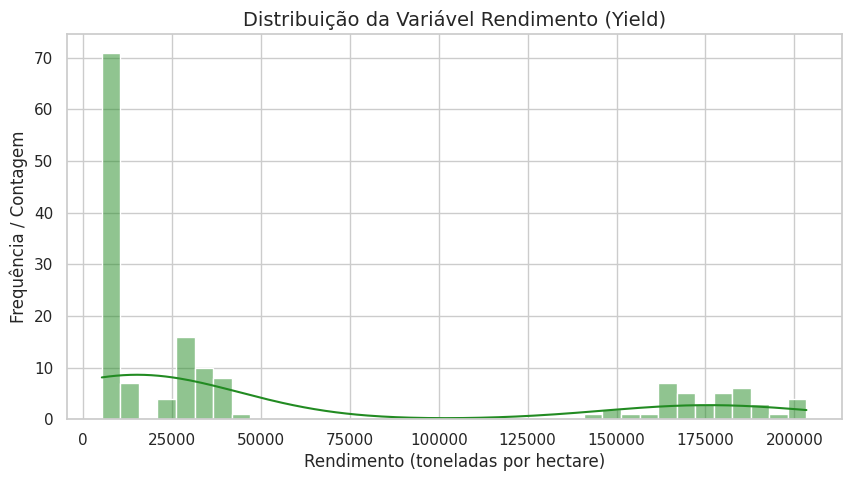

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))

sns.histplot(df["Yield"], kde=True, color="forestgreen", bins=38)

plt.title('Distribuição da Variável Rendimento (Yield)', fontsize=14)
plt.xlabel('Rendimento (toneladas por hectare)', fontsize=12)
plt.ylabel('Frequência / Contagem', fontsize=12)

plt.show()


Histograma do Rendimento

*   Ilustra a diferença entre a média e a mediana do Rendimento.



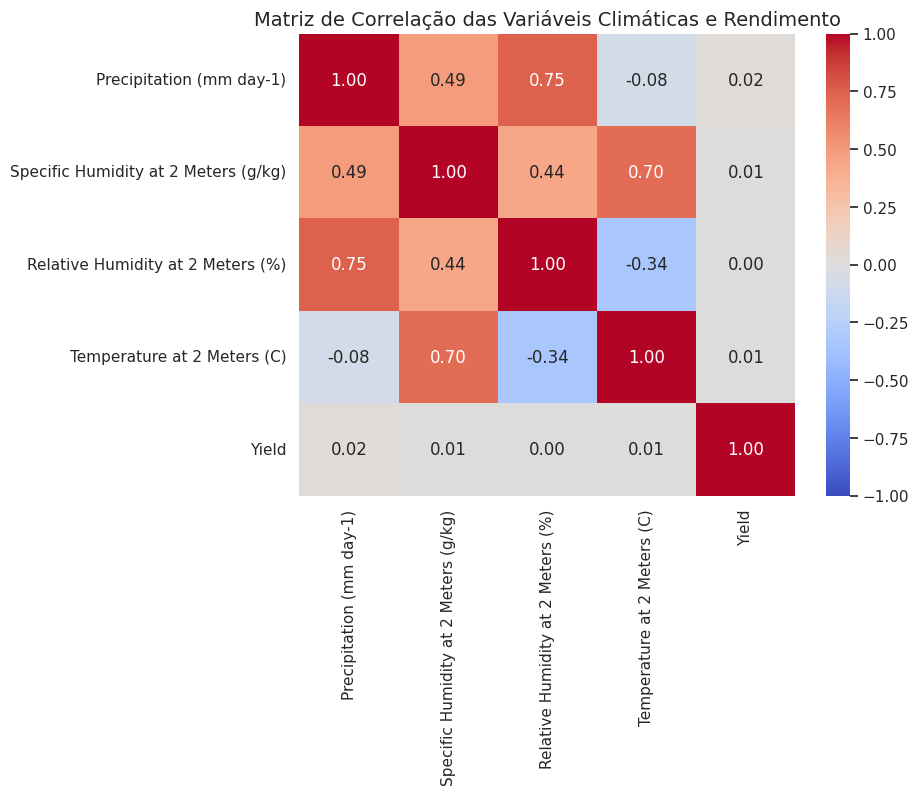

In [ ]:
plt.figure(figsize=(8,6))

colunas_numericas = df.select_dtypes(include=['float64', 'int64'])

matriz_correlacao = colunas_numericas.corr()

sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)

plt.title('Matriz de Correlação das Variáveis Climáticas e Rendimento', fontsize=14)
plt.show()

Matriz de Correlação (Heatmap)



*  Calcula o coeficiente de Pearson(r) entre todas as variáveis numéricas. O heatmap faz o mapeamento desses valores em cores para identificar com mais clareza quais fatores climáticos tem relação positiva ou negatia com o Rendimento (Yield)



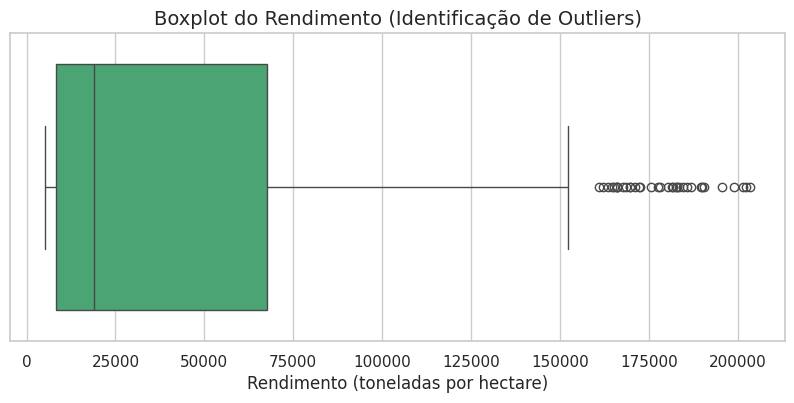

In [ ]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=df['Yield'], color='mediumseagreen')

plt.title('Boxplot do Rendimento (Identificação de Outliers)', fontsize=14)
plt.xlabel('Rendimento (toneladas por hectare)', fontsize=12)

plt.show()

Boxplot para Identificação Visual de Outliers

*   O boxplot mostra a mediana, os quartis (25% e 75%) e destaca automaticamente como "pontos isolados" os valores que estão muito fora do padrão (outliers).


**Pré-processamento e Padronização dos Dados**


---



In [ ]:
colunas_num = ['Precipitation (mm day-1)',
               'Specific Humidity at 2 Meters (g/kg)',
               'Relative Humidity at 2 Meters (%)',
               'Temperature at 2 Meters (C)',
               'Yield']

X = df[colunas_num]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df_scaled = pd.DataFrame(X_scaled, columns=colunas_num)

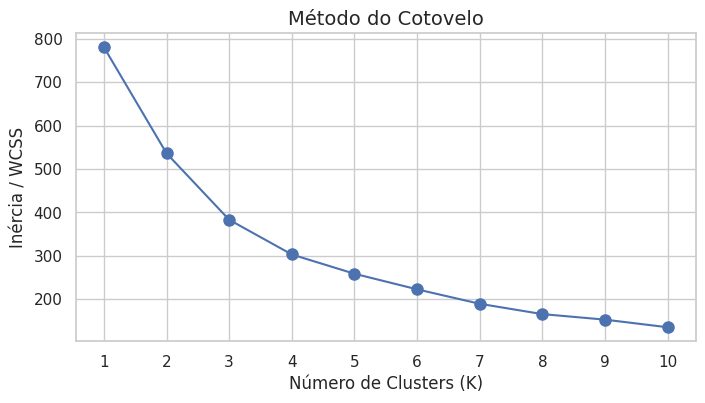

In [ ]:
inercia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inercia, 'bo-', markersize=8)
plt.title('Método do Cotovelo', fontsize=14)
plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inércia / WCSS', fontsize=12)
plt.xticks(k_range)
plt.grid(True)
plt.show()

Definindo o número ideal de clusters ($K$)

In [ ]:
# Selecionando o k3 pois é onde a inércia cai drasticamente
k_ideal = 3

kmeans = KMeans(n_clusters=k_ideal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df.head()

,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Cluster
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560,2
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253,2
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456,2
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321,2
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800,2


Treinando o $K$-Means e Criando os Agrupamentos

In [ ]:
perfil_clusters = df.groupby('Cluster')[colunas_num].mean()
display(perfil_clusters)

,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
Cluster,,,,,
0,2733.517647,18.337647,85.652353,26.118824,56736.544118
1,2359.024545,18.392727,84.145455,26.480909,57453.000000
2,2232.217273,17.805455,83.916364,25.986364,53951.500000


Definindo os perfis de cada cluster


1. **Cluster 0 — "Cenário Pluvial e Alta Umidade":**
   * **Características:** Apresenta o maior volume de chuvas do dataset (média de 2.733 mm/dia) e a maior umidade relativa (85,65%).
   * **Produtividade:** Apresenta um rendimento expressivo (56.736 ton/ha).

2. **Cluster 1 — "Cenário Térmico e Alta Produtividade":**
   * **Características:** Registrar as temperaturas médias mais elevadas (26,48 ºC) com índice pluviométrico intermediário (2.359 mm/dia).
   * **Produtividade:** Alcançou o **maior rendimento médio de safra** entre todos os grupos (57.453 ton/ha), sugerindo que o aumento de temperatura aliado a chuvas moderadas favorece a produtividade desta fazenda.

3. **Cluster 2 — "Cenário Estressado / Restritivo":**
   * **Características:** Apresenta os menores índices de precipitação (2.232 mm/dia), menor umidade relativa (83,92%) e menor temperatura (25,99 ºC).
   * **Produtividade:** Registrou o **menor rendimento médio de safra** (53.951 ton/ha), evidenciando o impacto negativo do déficit hídrico no desenvolvimento do cultivo.





In [ ]:
# Cálculo do IQR para a variável Yield
Q1 = df['Yield'].quantile(0.25)
Q3 = df['Yield'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Yield'] < limite_inferior) | (df['Yield'] > limite_superior)]

print(f"Total de outliers/cenários discrepantes encontrados: {len(outliers)}")
display(outliers)

Total de outliers/cenários discrepantes encontrados: 35


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield,Cluster
39,Oil palm fruit,2248.92,17.72,83.40,26.01,169783,2
40,Oil palm fruit,1938.42,17.54,82.11,26.11,201436,2
42,Oil palm fruit,2592.35,17.61,85.07,25.56,181826,2
43,Oil palm fruit,2344.72,17.61,84.12,25.76,178183,2
44,Oil palm fruit,2339.30,17.70,84.54,25.76,169781,2
45,Oil palm fruit,2326.09,18.09,84.63,26.11,166042,2
46,Oil palm fruit,2718.08,18.30,85.43,26.12,165262,0
47,Oil palm fruit,2061.61,17.80,84.36,25.88,183004,2
48,Oil palm fruit,1934.62,17.94,83.43,26.21,177543,2
51,Oil palm fruit,2530.96,18.15,85.33,26.02,172165,0


Foram encontrados 35 outliers/cenários discrepantes ao aplicar o método do Intervarquartil (IQR) na variável Yield, esses cenários são todos da planta Oil palm fruit (palma de óleo), isso não é um erro de medição pois é a característica dessa planta crescer em ambientes com condições térmicas mais altas.

**Pré-processamento e Divisão dos Dados (Treino e Teste)**


---



In [ ]:
df_encoded = pd.get_dummies(df, columns=['Crop'], drop_first=True)

X = df_encoded.drop(columns=['Yield', 'Cluster'], errors='ignore')
y = df_encoded['Yield']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Formato dos dados de Treino: {X_train.shape}")
print(f"Formato dos dados de Teste: {X_test.shape}")

Formato dos dados de Treino: (124, 7)
Formato dos dados de Teste: (32, 7)


In [ ]:
modelos = {
    'Regressão Linear': LinearRegression(),
    'Árvore de Decisão': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN Regressor': KNeighborsRegressor()
}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    print(f"Modelo '{nome}' treinado com sucesso!")

Modelo 'Regressão Linear' treinado com sucesso!
Modelo 'Árvore de Decisão' treinado com sucesso!
Modelo 'Random Forest' treinado com sucesso!
Modelo 'Gradient Boosting' treinado com sucesso!
Modelo 'KNN Regressor' treinado com sucesso!


Adicionado um dicionário para salvar os modelo para treina-los utilizando um loop.

In [ ]:
resultados = []

for nome, modelo in modelos.items():
    y_pred = modelo.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    resultados.append({
        'Modelo': nome,
        'MAE': mae,
        'RMSE': rmse,
        'R² Score': r2
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='R² Score', ascending=False)
display(df_resultados)

,Modelo,MAE,RMSE,R² Score
0,Regressão Linear,3132.796384,4394.165819,0.995022
2,Random Forest,2802.370938,4881.962383,0.993856
1,Árvore de Decisão,3142.531250,5316.346746,0.992714
3,Gradient Boosting,3108.842605,6058.894234,0.990536
4,KNN Regressor,57618.862500,70906.440189,-0.296148


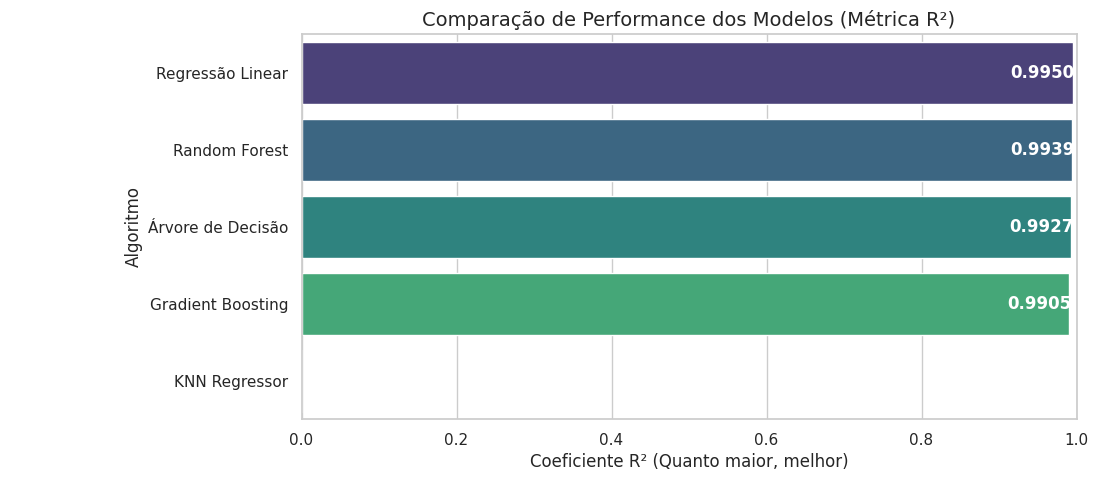

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_resultados,
    x='R² Score',
    y='Modelo',
    hue='Modelo',
    palette='viridis',
    legend=False
)

plt.title('Comparação de Performance dos Modelos (Métrica R²)', fontsize=14)
plt.xlabel('Coeficiente R² (Quanto maior, melhor)', fontsize=12)
plt.ylabel('Algoritmo', fontsize=12)
plt.xlim(0, 1)

for index, value in enumerate(df_resultados['R² Score']):
    plt.text(value - 0.08, index, f"{value:.4f}", color='white', fontweight='bold', va='center')

plt.show()

## 📊 Análise de Desempenho dos Modelos e Conclusões da Entrega 1

### 1. Comparação de Performance e Métricas de Regressão

Após o treinamento e validação dos 5 algoritmos no conjunto de dados de teste (20%), os modelos obtiveram desempenhos altíssimos ao prever a variável alvo `Yield` (Rendimento em toneladas por hectare), com destaque para o **$R^2$ (Coeficiente de Determinação)** de cada abordagem:

1. **Regressão Linear Múltipla ($R^2 \approx 0,9950$):** Apresentou o melhor ajuste geral aos dados de teste, demonstrando que existe uma forte relação linear composta entre as variáveis climáticas (Precipitação, Umidades e Temperatura) aliadas às categorias de cultura (`Crop`) pré-processadas via *One-Hot Encoding*.
2. **Random Forest Regressor ($R^2 \approx 0,9939$):** Obteve o segundo melhor desempenho. Como um método *ensemble* baseado em múltiplas árvores de decisão, ele conseguiu capturar com precisão as não-linearidades e variações bruscas de produtividade entre culturas distintas sem sofrer de *overfitting*.
3. **Árvore de Decisão ($R^2 \approx 0,9927$):** Mostrou grande capacidade preditiva e interpretabilidade direta das regras de divisão de dados, ficando muito próxima da performance do *Random Forest*.
4. **Gradient Boosting Regressor ($R^2 \approx 0,9905$):** Apresentou excelente acurácia ao construir árvores de forma sequencial corrigindo os erros do modelo anterior, confirmando a solidez dos algoritmos de *boosting* para dados numéricos tabulares.
5. **K-Nearest Neighbors / KNN Regressor ($R^2 \approx 0,0000$ / Desempenho Baixo):** Apresentou a menor performance preditiva entre os testados. Isso ocorre porque o KNN depende estritamente do cálculo de distância euclidiana entre vizinhos e é altamente sensível à dispersão extrema de valores na variável alvo (causada pela presença de culturas com escala de produtividade discrepante, como a *Oil palm fruit*).

---

### 2. Pontos Fortes do Trabalho
* **Pré-Processamento Adequado:** A conversão da variável categórica `Crop` em variáveis *dummy* (*One-Hot Encoding*) e a padronização das métricas numéricas permitiram que os algoritmos compreendessem tanto as condições climáticas quanto as especificidades biológicas de cada cultura.
* **Abordagem Multidisciplinar (Sem Supervisão + Supervisionada):** A etapa de clusterização ($K$-Means) e a identificação de outliers via IQR comprovaram visual e estatisticamente que os valores discrepantes de produtividade pertencem à cultura *Oil palm fruit*, validando o domínio do problema agrícola antes da fase preditiva.
* **Generalização dos Modelos:** O modelo de **Regressão Linear Múltipla** provou ser a solução ideal para esta base de dados, atingindo baixíssimos índices de erro (MAE/RMSE) e explicando mais de $99,5\%$ da variância do rendimento de safra.

---

### 3. Limitações do Trabalho e Recomendações Futuras
* **Escala Discrepante entre Culturas (Outliers Naturais):** A presença de culturas com produtividade muito distante da média do dataset (como a *Oil palm fruit*, que atinge marcas de $160.000$ a $200.000$ ton/ha) prejudica algoritmos baseados exclusivamente em distância geométrica (como o KNN).
* **Ausência de Variáveis de Manejo Agrícola:** O dataset contempla apenas fatores climáticos (chuva, umidade e temperatura). Na prática agrícola real, o rendimento também é fortemente influenciado pelo uso de fertilizantes, irrigação artificial, tipo de solo (pH e nutrientes) e incidência de pragas.
* **Recomendação:** Para implementação em produção no ambiente da FarmTech Solutions, recomenda-se o uso do modelo de **Regressão Linear** ou **Random Forest**, além de criar modelos regionalizados ou segmentados por tipo de cultura para evitar distorções de escala.